# Simple Linear Regression Implementation

In this notebook, we'll implement and demonstrate a simple Linear Regression algorithm based on a given set of training data. We'll read the training data from a CSV file and then build a model to make predictions.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set up plotting style
plt.style.use('seaborn')
%matplotlib inline

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

## Part 1: Creating a Sample Dataset

First, let's create a sample CSV file with data for our linear regression model. We'll create a dataset relating study hours to exam scores.

In [2]:
# Create sample data
np.random.seed(42)
# Hours studied
hours_studied = np.random.uniform(1, 10, 100)
# Exam score with some noise (linear relationship with study hours)
exam_scores = 40 + 5 * hours_studied + np.random.normal(0, 5, 100)

# Create DataFrame
data = pd.DataFrame({
    'Hours_Studied': hours_studied,
    'Exam_Score': exam_scores
})

# Preview the data
print("Sample Data:")
print(data.head())

# Save to CSV file
data.to_csv('sample_data.csv', index=False)
print("\nData saved to sample_data.csv")

Sample Data:
   Hours_Studied  Exam_Score
0       4.370861   62.289541
1       9.556429   86.287107
2       7.587945   78.398531
3       6.387926   62.001787
4       2.404168   50.922479

Data saved to sample_data.csv


## Part 2: Data Exploration

Let's load the data from the CSV file and explore it.

In [3]:
# Read data from the CSV file
data = pd.read_csv('sample_data.csv')

# Display basic information about the dataset
print("Dataset Info:")
print(f"Number of records: {len(data)}")
print("\nStatistical Summary:")
print(data.describe())

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Info:
Number of records: 100

Statistical Summary:
       Hours_Studied  Exam_Score
count     100.000000  100.000000
mean        5.231627   66.152732
std         2.677405   13.481021
min         1.049699   42.438107
25%         2.738807   54.399230
50%         5.177282   64.140673
75%         7.571828   78.021551
max         9.881982   93.319027

Missing Values:
Hours_Studied    0
Exam_Score       0
dtype: int64


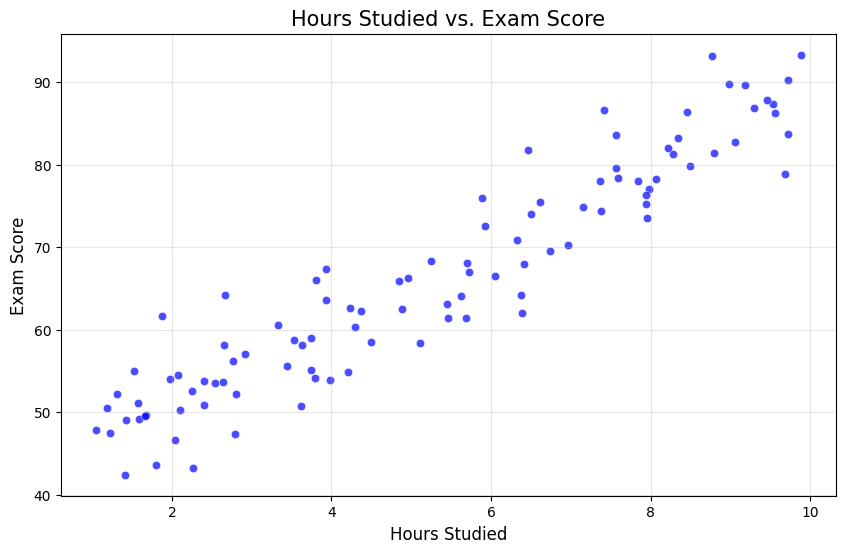

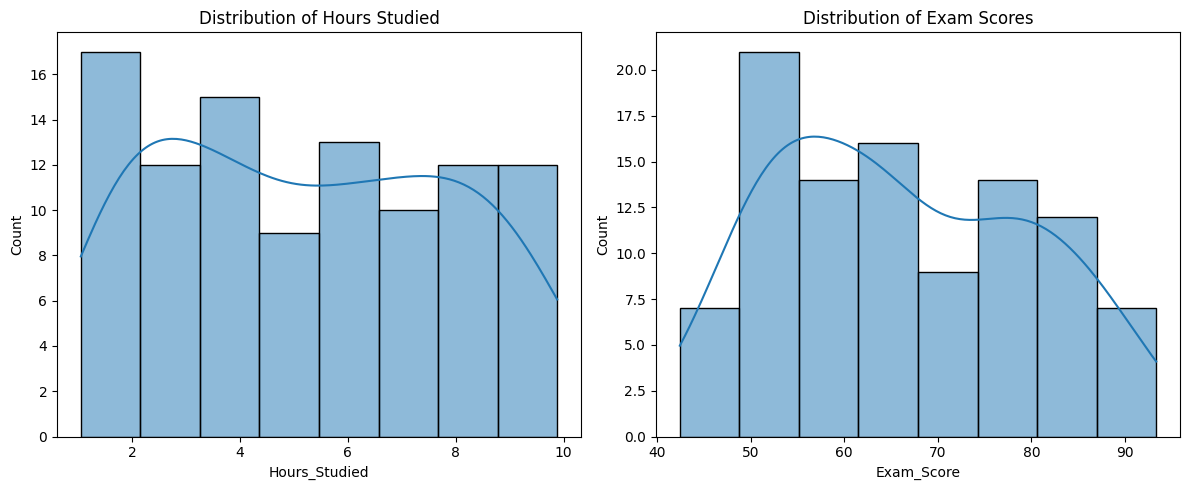

In [4]:
# Visualize the data
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=data, alpha=0.7, color='blue')
plt.title('Hours Studied vs. Exam Score', fontsize=15)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Distribution of features
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['Hours_Studied'], kde=True)
plt.title('Distribution of Hours Studied')

plt.subplot(1, 2, 2)
sns.histplot(data['Exam_Score'], kde=True)
plt.title('Distribution of Exam Scores')

plt.tight_layout()
plt.show()

## Part 3: Implementing Simple Linear Regression from Scratch

Now, let's implement a simple linear regression algorithm from scratch.

In [5]:
class SimpleLinearRegression:
    def __init__(self):
        # Initialize slope and intercept
        self.slope = 0
        self.intercept = 0
        
    def fit(self, X, y):
        """
        Fit a linear model using the least squares approach
        
        Parameters:
        X : array-like, shape (n_samples,)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        """
        # Convert inputs to numpy arrays
        X = np.array(X)
        y = np.array(y)
        
        # Number of observations
        n = len(X)
        
        # Calculate means
        mean_X = np.mean(X)
        mean_y = np.mean(y)
        
        # Calculate slope using the formula:
        # slope = sum((x_i - mean_x) * (y_i - mean_y)) / sum((x_i - mean_x)^2)
        numerator = sum((X - mean_X) * (y - mean_y))
        denominator = sum((X - mean_X) ** 2)
        
        self.slope = numerator / denominator
        
        # Calculate intercept using the formula:
        # intercept = mean_y - slope * mean_x
        self.intercept = mean_y - self.slope * mean_X
        
        return self
    
    def predict(self, X):
        """
        Predict using the linear model
        
        Parameters:
        X : array-like, shape (n_samples,)
            Samples
            
        Returns:
        y_pred : array, shape (n_samples,)
            Predicted values
        """
        X = np.array(X)
        return self.intercept + self.slope * X
    
    def get_params(self):
        """
        Get the model parameters
        
        Returns:
        dict : Dictionary containing the slope and intercept
        """
        return {'slope': self.slope, 'intercept': self.intercept}
    
    def score(self, X, y):
        """
        Calculate the coefficient of determination (R^2)
        
        Parameters:
        X : array-like, shape (n_samples,)
            Test samples
        y : array-like, shape (n_samples,)
            True values for X
            
        Returns:
        r2_score : float
            R^2 score
        """
        X = np.array(X)
        y = np.array(y)
        
        y_pred = self.predict(X)
        
        # Total sum of squares
        ss_tot = sum((y - np.mean(y)) ** 2)
        
        # Residual sum of squares
        ss_res = sum((y - y_pred) ** 2)
        
        # Calculate R^2
        r2 = 1 - (ss_res / ss_tot)
        
        return r2

## Part 4: Train-Test Split

Let's split our dataset into training and testing sets.

In [6]:
# Define features (X) and target (y)
X = data['Hours_Studied'].values
y = data['Exam_Score'].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing data shape: X_test = {X_test.shape}, y_test = {y_test.shape}")

Training data shape: X_train = (80,), y_train = (80,)
Testing data shape: X_test = (20,), y_test = (20,)


## Part 5: Training and Evaluating Our Linear Regression Model

Now, let's train our custom linear regression model and evaluate its performance.

In [7]:
# Create and train our custom linear regression model
custom_model = SimpleLinearRegression()
custom_model.fit(X_train, y_train)

# Get model parameters
params = custom_model.get_params()
print(f"Model Equation: y = {params['slope']:.4f} * x + {params['intercept']:.4f}")

# Make predictions
y_train_pred = custom_model.predict(X_train)
y_test_pred = custom_model.predict(X_test)

# Calculate metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = custom_model.score(X_train, y_train)
test_r2 = custom_model.score(X_test, y_test)

print(f"Training MSE: {train_mse:.4f}")
print(f"Testing MSE: {test_mse:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²: {test_r2:.4f}")

Model Equation: y = 4.7770 * x + 40.9375
Training MSE: 21.1920
Testing MSE: 16.3425
Training R²: 0.8809
Testing R²: 0.9120


## Part 6: Comparing with Scikit-learn's Implementation

Let's compare our implementation with scikit-learn's LinearRegression.

In [8]:
# Create and train scikit-learn's linear regression model
sklearn_model = LinearRegression()
sklearn_model.fit(X_train.reshape(-1, 1), y_train)

# Get model parameters
sklearn_slope = sklearn_model.coef_[0]
sklearn_intercept = sklearn_model.intercept_
print(f"Scikit-learn Model Equation: y = {sklearn_slope:.4f} * x + {sklearn_intercept:.4f}")

# Make predictions
sklearn_y_train_pred = sklearn_model.predict(X_train.reshape(-1, 1))
sklearn_y_test_pred = sklearn_model.predict(X_test.reshape(-1, 1))

# Calculate metrics
sklearn_train_mse = mean_squared_error(y_train, sklearn_y_train_pred)
sklearn_test_mse = mean_squared_error(y_test, sklearn_y_test_pred)
sklearn_train_r2 = sklearn_model.score(X_train.reshape(-1, 1), y_train)
sklearn_test_r2 = sklearn_model.score(X_test.reshape(-1, 1), y_test)

print(f"Scikit-learn Training MSE: {sklearn_train_mse:.4f}")
print(f"Scikit-learn Testing MSE: {sklearn_test_mse:.4f}")
print(f"Scikit-learn Training R²: {sklearn_train_r2:.4f}")
print(f"Scikit-learn Testing R²: {sklearn_test_r2:.4f}")

Scikit-learn Model Equation: y = 4.7770 * x + 40.9375
Scikit-learn Training MSE: 21.1920
Scikit-learn Testing MSE: 16.3425
Scikit-learn Training R²: 0.8809
Scikit-learn Testing R²: 0.9120


## Part 7: Visualizing the Regression Line

Let's visualize our data with the regression line.

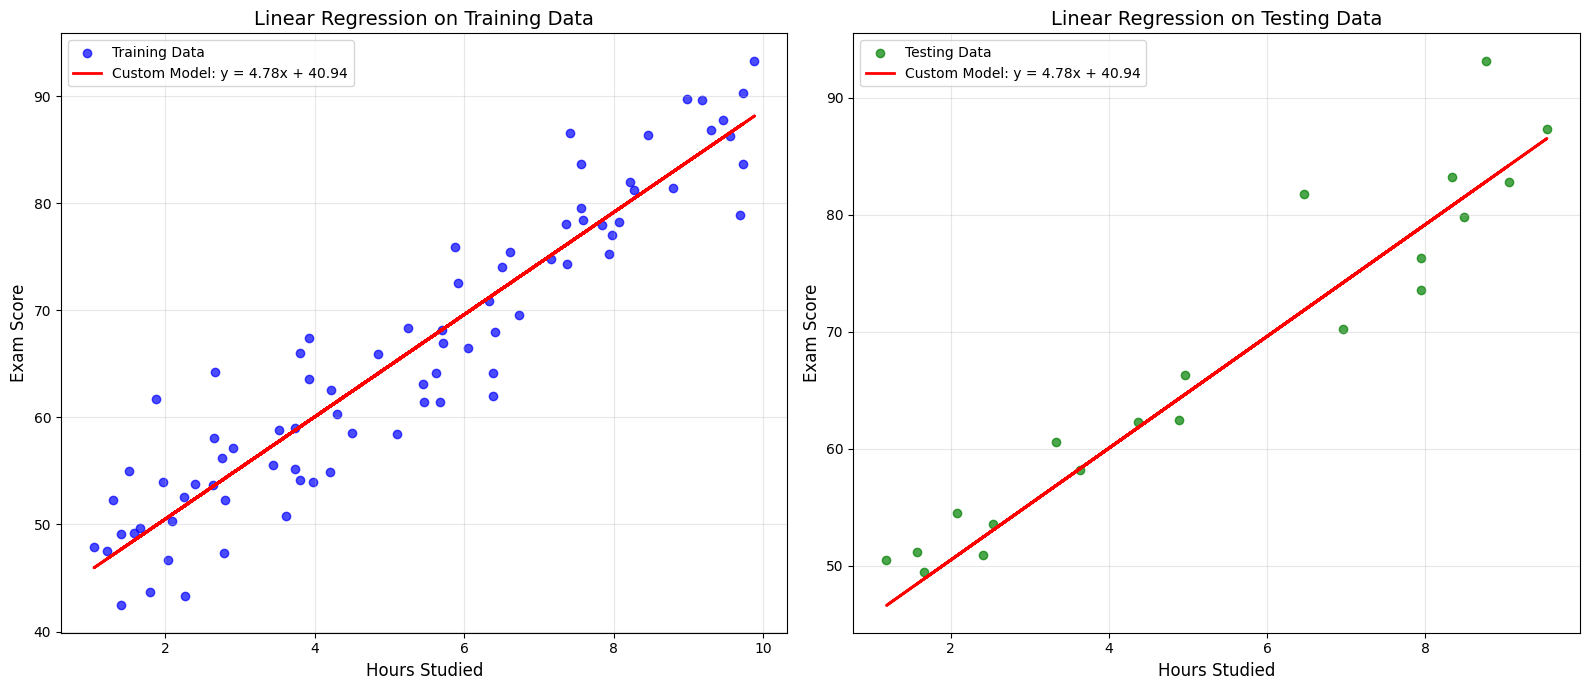

In [9]:
# Create a figure with subplots
plt.figure(figsize=(16, 7))

# Training data plot
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color='blue', alpha=0.7, label='Training Data')
plt.plot(X_train, y_train_pred, color='red', linewidth=2, label=f'Custom Model: y = {params["slope"]:.2f}x + {params["intercept"]:.2f}')
plt.title('Linear Regression on Training Data', fontsize=14)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Testing data plot
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='green', alpha=0.7, label='Testing Data')
plt.plot(X_test, y_test_pred, color='red', linewidth=2, label=f'Custom Model: y = {params["slope"]:.2f}x + {params["intercept"]:.2f}')
plt.title('Linear Regression on Testing Data', fontsize=14)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Part 8: Making Predictions on New Data

Let's use our model to predict exam scores for new study hour values.

Predictions for new study hours:
   Hours_Studied  Predicted_Score
0              2        50.491593
1              4        60.045645
2              6        69.599698
3              8        79.153751
4             10        88.707803


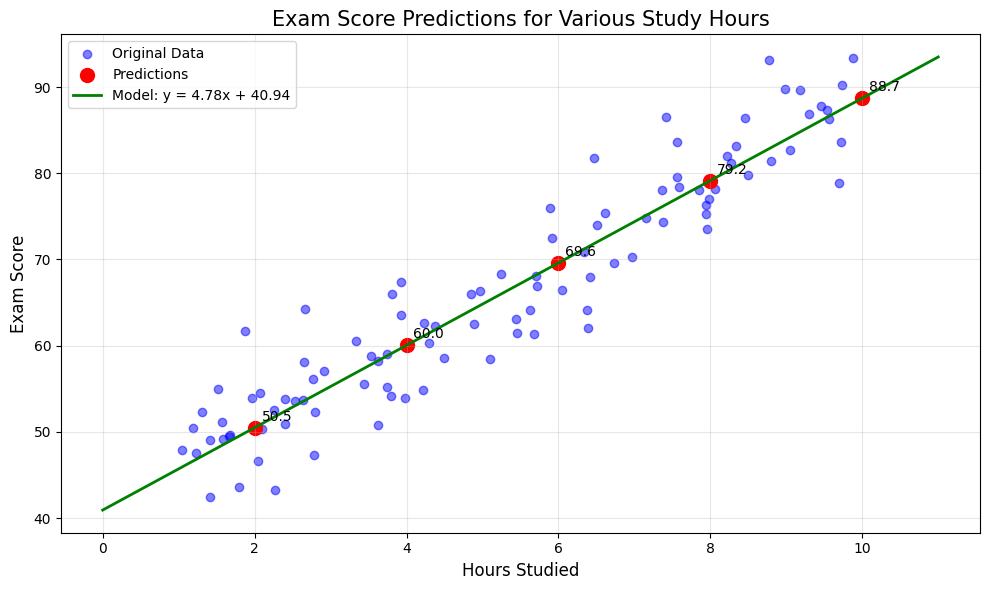

In [10]:
# New study hours to predict
new_hours = np.array([2, 4, 6, 8, 10])

# Predict using custom model
predicted_scores = custom_model.predict(new_hours)

# Create a dataframe for better visualization
prediction_df = pd.DataFrame({
    'Hours_Studied': new_hours,
    'Predicted_Score': predicted_scores
})

print("Predictions for new study hours:")
print(prediction_df)

# Visualize predictions
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Original Data')
plt.scatter(new_hours, predicted_scores, color='red', s=100, label='Predictions')

# Add a line for the linear model across the entire range
x_range = np.linspace(0, 11, 100)
y_range = custom_model.predict(x_range)
plt.plot(x_range, y_range, color='green', linewidth=2, label=f'Model: y = {params["slope"]:.2f}x + {params["intercept"]:.2f}')

# Add labels and annotations
for i, (hour, score) in enumerate(zip(new_hours, predicted_scores)):
    plt.annotate(f"{score:.1f}", (hour, score), xytext=(5, 5), textcoords='offset points')

plt.title('Exam Score Predictions for Various Study Hours', fontsize=15)
plt.xlabel('Hours Studied', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Part 9: Residual Analysis

Let's analyze the residuals (errors) of our model.

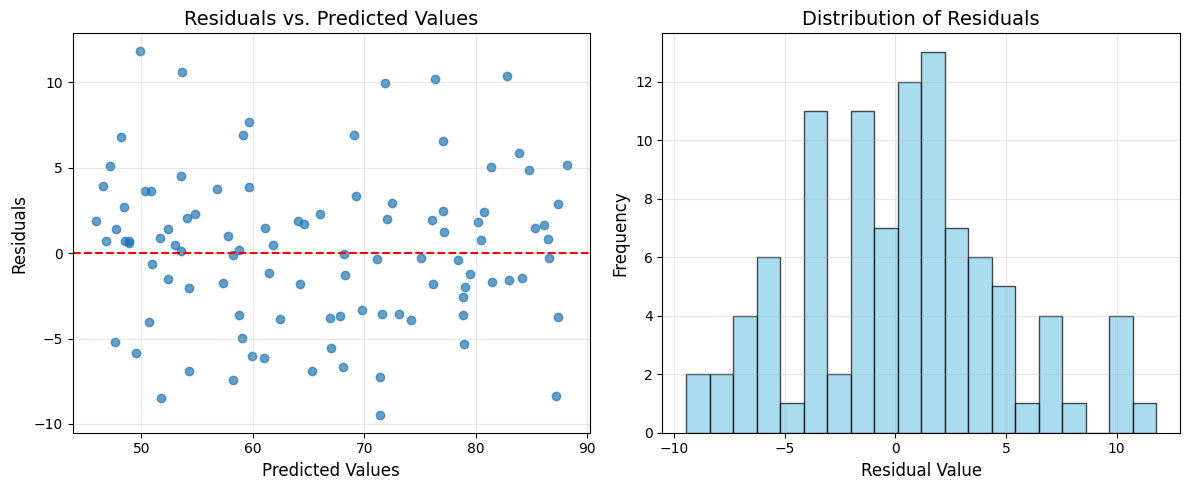

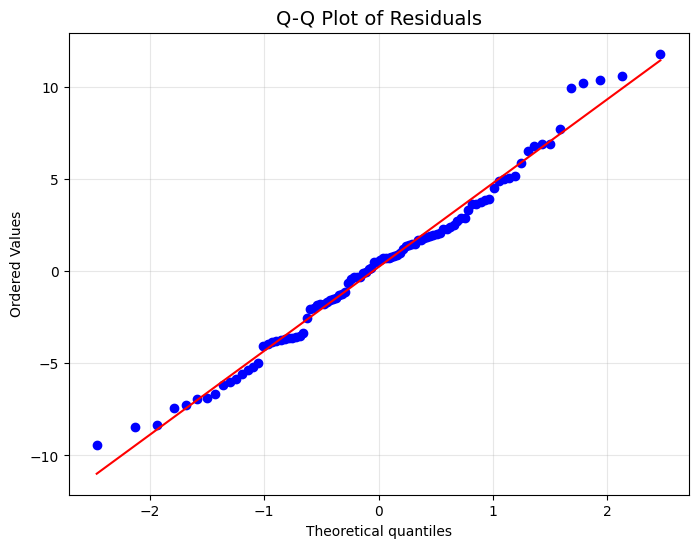

In [11]:
# Calculate residuals
residuals = y - custom_model.predict(X)

plt.figure(figsize=(12, 5))

# Residuals vs. Predicted values
plt.subplot(1, 2, 1)
plt.scatter(custom_model.predict(X), residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, alpha=0.3)

# Histogram of residuals
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals', fontsize=14)
plt.xlabel('Residual Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Q-Q plot for normality check
from scipy import stats
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## Conclusion

In this notebook, we've successfully implemented a simple linear regression algorithm from scratch and demonstrated its application on a dataset. We:

1. Created and explored a sample dataset
2. Implemented a simple linear regression algorithm from scratch
3. Evaluated the model's performance using MSE and R² metrics
4. Compared our implementation with scikit-learn's LinearRegression
5. Visualized the regression line and made predictions on new data
6. Performed residual analysis to assess model assumptions

Our model shows that there is a strong positive linear relationship between hours studied and exam scores. The equation of our linear regression model is:

**Exam Score = (Slope) × Hours Studied + (Intercept)**

The model can be used to predict the expected exam score for a given number of study hours, which could help students plan their study schedules effectively.